In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.chdir('../')  


In [2]:
df = pd.read_json('data/raw/gazeta_train.jsonl', lines=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60964 entries, 0 to 60963
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   date     60964 non-null  datetime64[us]
 1   url      60964 non-null  str           
 2   summary  60964 non-null  str           
 3   title    60964 non-null  str           
 4   text     60964 non-null  str           
dtypes: datetime64[us](1), str(4)
memory usage: 521.8 MB


Статистика по длине текста:
count    60964.000000
mean      4525.268831
std       1252.317488
min        127.000000
25%       3810.000000
50%       4294.000000
75%       5069.000000
max      10434.000000
Name: text_length, dtype: float64

Статистика по длине краткого описания:
count    60964.000000
mean       310.945804
std         86.924811
min         75.000000
25%        245.000000
50%        311.000000
75%        375.000000
max        614.000000
Name: summary_length, dtype: float64


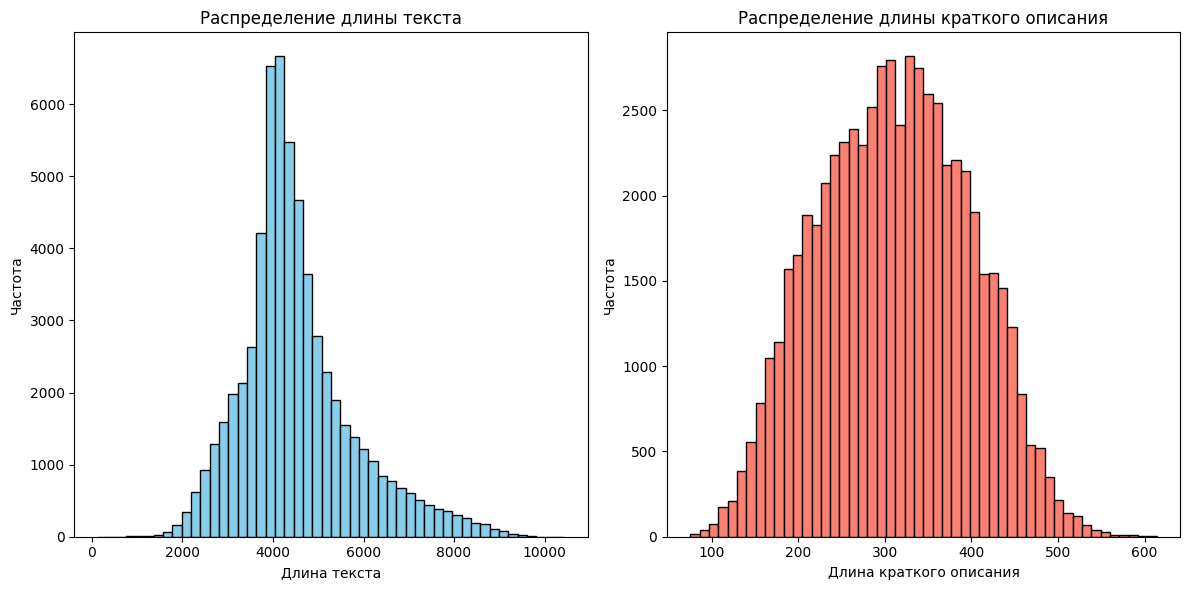

In [3]:
# Рассчитываем длину текста и краткого описания
df['text_length'] = df['text'].apply(len)
df['summary_length'] = df['summary'].apply(len)

# Статистика
text_stats = df['text_length'].describe()
summary_stats = df['summary_length'].describe()

# Печатаем статистику
print("Статистика по длине текста:")
print(text_stats)

print("\nСтатистика по длине краткого описания:")
print(summary_stats)

# Строим графики распределения
plt.figure(figsize=(12, 6))

# Дистрибуция длины текста
plt.subplot(1, 2, 1)
plt.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title("Распределение длины текста")
plt.xlabel("Длина текста")
plt.ylabel("Частота")

# Дистрибуция длины краткого описания
plt.subplot(1, 2, 2)
plt.hist(df['summary_length'], bins=50, color='salmon', edgecolor='black')
plt.title("Распределение длины краткого описания")
plt.xlabel("Длина краткого описания")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

In [4]:
# Поиск дублирующихся заголовков
duplicates_title = df[df.duplicated(subset='title', keep=False)]

# Поиск дублирующихся текстов
duplicates_text = df[df.duplicated(subset='text', keep=False)]

# Выводим результаты
print(f"Количество дублирующихся заголовков: {duplicates_title.shape[0]}")
print(duplicates_title[['title', 'url', 'date']].head())  # Печатаем примеры

print(f"\nКоличество дублирующихся текстов: {duplicates_text.shape[0]}")
print(duplicates_text[['title', 'text', 'url', 'date']].head())  # Печатаем примеры

Количество дублирующихся заголовков: 401
                    title                                                url  \
12  Google закрыл Windows  https://www.gazeta.ru/techzone/2010/06/01_a_33...   
13  Google закрыл Windows  https://www.gazeta.ru/business/2010/06/01/3378...   
71          ЕГЭ без купюр  https://www.gazeta.ru/social/2010/06/03/337974...   
72          ЕГЭ без купюр  https://www.gazeta.ru/education/2010/06/04_a_3...   
80       Фильтруй коммент  https://www.gazeta.ru/techzone/2010/06/03_a_33...   

                  date  
12 2010-06-01 19:08:20  
13 2010-06-01 19:08:20  
71 2010-06-03 21:51:52  
72 2010-06-03 21:51:52  
80 2010-06-04 10:50:43  

Количество дублирующихся текстов: 240
                                                title  \
71                                      ЕГЭ без купюр   
72                                      ЕГЭ без купюр   
80                                   Фильтруй коммент   
81                                   Фильтруй коммент   
93  

In [13]:
# 1) оставить только summary и text
df = df[["summary", "text"]].copy()

# 2) удалить дубликаты по text
df = df.drop_duplicates(subset=["text"], keep="first").reset_index(drop=True)
df = df.drop_duplicates(subset=["summary"], keep="first").reset_index(drop=True)

print(df.shape)
print(df.head())

(55543, 2)
                                             summary  \
0  С 2011 года правительство отменяет самый раздр...   
1  Британские затворники, московские модники, бра...   
2  Совбез ООН собрался на экстренное совещание дл...   
3  Ураган «Агата» в Центральной Америке унес жизн...   
4  Правительство хочет сдержать рост тарифов есте...   

                                                text  
0  Сегодня транспортный налог начисляется в завис...  
1  Словосочетание «музыкальный кинофестиваль» уже...  
2  После более чем 12-часовых консультаций Совет ...  
3  Жертвами урагана «Агата», обрушившегося на Цен...  
4  Решение ограничить рост тарифов естественных м...  


In [14]:
df = df[df["text"].str.len().between(2000, 7000)]
df = df[df["summary"].str.len().between(150, 500)]
df = df.reset_index(drop=True)

print(df.shape)
df.info()
df_prepared = df

(55543, 2)
<class 'pandas.DataFrame'>
RangeIndex: 55543 entries, 0 to 55542
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   summary  55543 non-null  str  
 1   text     55543 non-null  str  
dtypes: str(2)
memory usage: 451.0 MB


Статистика по длине текста:
count    55543.000000
mean      4354.422015
std        972.526244
min       2000.000000
25%       3796.000000
50%       4243.000000
75%       4884.000000
max       7000.000000
Name: text_length, dtype: float64

Статистика по длине краткого описания:
count    55543.000000
mean       311.695749
std         80.661718
min        150.000000
25%        249.000000
50%        311.000000
75%        372.000000
max        500.000000
Name: summary_length, dtype: float64


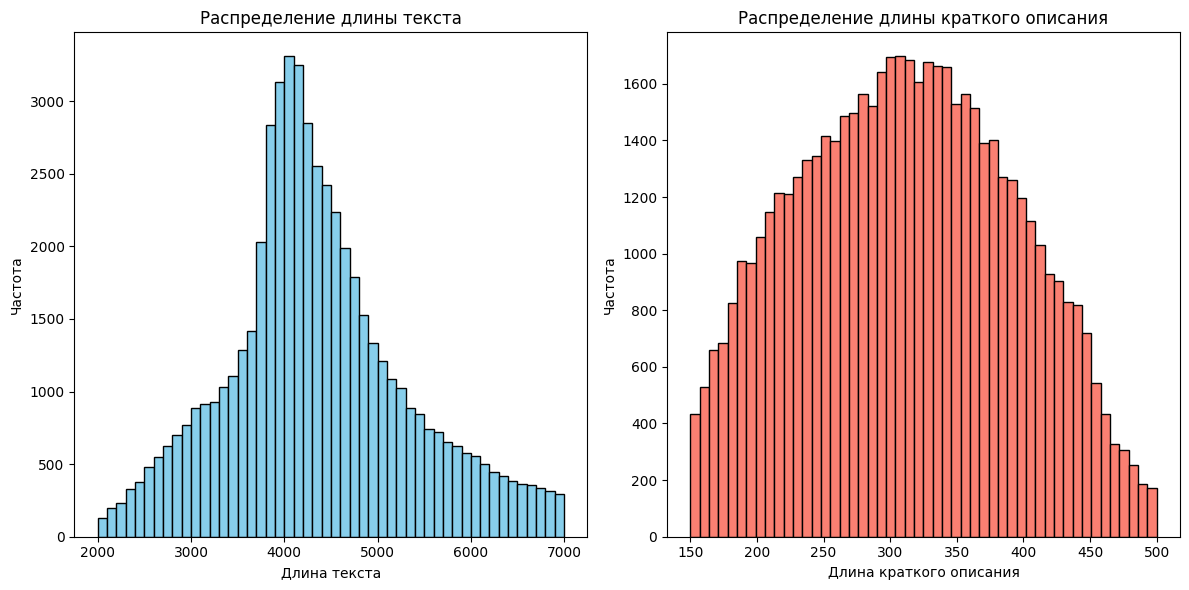

In [15]:
df['text_length'] = df['text'].apply(len)
df['summary_length'] = df['summary'].apply(len)

text_stats = df['text_length'].describe()
summary_stats = df['summary_length'].describe()

print("Статистика по длине текста:")
print(text_stats)

print("\nСтатистика по длине краткого описания:")
print(summary_stats)

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df['text_length'], bins=50, color='skyblue', edgecolor='black')
plt.title("Распределение длины текста")
plt.xlabel("Длина текста")
plt.ylabel("Частота")

plt.subplot(1, 2, 2)
plt.hist(df['summary_length'], bins=50, color='salmon', edgecolor='black')
plt.title("Распределение длины краткого описания")
plt.xlabel("Длина краткого описания")
plt.ylabel("Частота")

plt.tight_layout()
plt.show()

100%|██████████| 55/55 [00:38<00:00,  1.44it/s]


TEXT tokens: n=55543 | min=573 | p50=1458 p75=1684 p90=1981 p95=2149 p99=2393 | max=3084
SUMMARY tokens: n=55543 | min=39 | p50=109 p75=129 p90=146 p95=155 p99=171 | max=209
Saved: text_token_len_hist.png, summary_token_len_hist.png


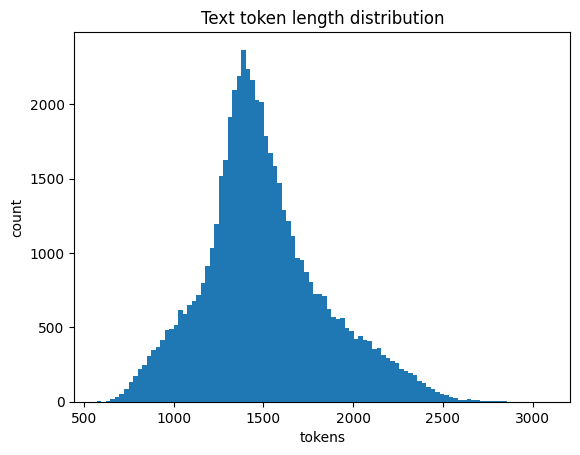

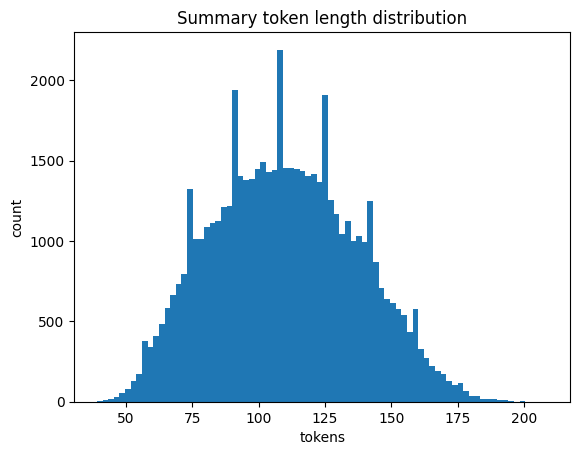

In [16]:
import pandas as pd
import numpy as np
from transformers import AutoTokenizer
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

MODEL_NAME = "unsloth/Qwen2.5-0.5B-bnb-4bit"
df = df_prepared

BATCH_SIZE = 1024

tok = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)

def batch_token_lengths(texts):
    enc = tok(
        texts,
        add_special_tokens=False,
        padding=False,
        truncation=False,
        return_length=True,
    )
    if "length" in enc:
        return enc["length"]
    return [len(x) for x in enc["input_ids"]]

text_lens = []
sum_lens  = []

for i in tqdm(range(0, len(df), BATCH_SIZE)):
    bt = df["text"].iloc[i:i+BATCH_SIZE].astype(str).tolist()
    bs = df["summary"].iloc[i:i+BATCH_SIZE].astype(str).tolist()
    text_lens.extend(batch_token_lengths(bt))
    sum_lens.extend(batch_token_lengths(bs))

text_lens = np.array(text_lens, dtype=np.int32)
sum_lens  = np.array(sum_lens, dtype=np.int32)

def stats(arr, name):
    qs = np.percentile(arr, [50, 75, 90, 95, 99])
    print(
        f"{name}: n={arr.size} | min={arr.min()} | "
        f"p50={int(qs[0])} p75={int(qs[1])} p90={int(qs[2])} p95={int(qs[3])} p99={int(qs[4])} | "
        f"max={arr.max()}"
    )

stats(text_lens, "TEXT tokens")
stats(sum_lens,  "SUMMARY tokens")

plt.figure()
plt.hist(text_lens, bins=100)
plt.title("Text token length distribution")
plt.xlabel("tokens")
plt.ylabel("count")
plt.savefig("text_token_len_hist.png", dpi=200, bbox_inches="tight")

plt.figure()
plt.hist(sum_lens, bins=80)
plt.title("Summary token length distribution")
plt.xlabel("tokens")
plt.ylabel("count")
plt.savefig("summary_token_len_hist.png", dpi=200, bbox_inches="tight")

print("Saved: text_token_len_hist.png, summary_token_len_hist.png")